<a href="https://colab.research.google.com/github/OSGeoLabBp/tutorials/blob/master/hungarian/pointcloud/pointclouds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pontfelhők feldolgozása

Ez az összeálltás a gita Műszaki térinformatika egyesület 2026. évi konferenciájának workshopjához készült. A tananyag és a használt képek a BME Általános és Felsőgeodézia Tanszék Geo4All laborjának GitHub oldaláról letölthetők.

## Bevezetés

### Pontfelhőkben tárolt adatok

A pontfelhőkben a pozíció mellett további adatok is tárolásra kerülhetnek.

### Pontfelhők tárolási formátumai

A térinformatikához hasonlóan sokféle adatformátum használatos a pontfelhő állományok tárolására. Ezek között találhatók nyílt formátumok és zárt formátumok.

A nyílt formátumok esetén az állomány belső struktúrájának leírása bárki számára elérhető és ez alapján készíthet olyan programot, mely a formátumot olvasni és írni képes. Néhány, Magyarországon elterjedt nyílt polfelhő formátum: LAS, LAZ, e57, XYZ, PLY, PCD

A zárt formátumok egyes kereskedelmi szotverekhez kötődnek, azokat csak a megfelelő szoftvercsomag megvásárlása esetén tudjuk kezelni. Ilyen formátumok például az RCS és a RCP.

Az egyes tárolási formátumok közötti választásnál mérlegelni kell a metaadatok (intenzitás, szín, osztályozás) megőrzését, a fájlméretet/tömöríthetőséget illetve a szoftver kompatibilitást.

### Pontfelhőlhők előállítási technológiái

A pontfelhők előállításának két fő technológiája létezik a lézeres távmérés (LiDAR) és a fotogrammetria (SfM). A LiDAR technológia több részterületre bontható TLS, ALS, SLAM, stb.

### Nyílt forráskódú programok pontfelhők kezelésére

*   CloudCompare - grafikus felhasználói felület és programozási
*   PDAL - programkönyvtár és parancssori eszközök
*   PCL - programkönyvtár
*   Open3D - programkönyvtár Python programokhoz
*   Potree - internetes megjelenítés



## Nyers pontfelhők előkészítése

A nyers pontfelhők jellemzően zajjal terheltek. Olyan pontok jelenhetnek benne,melyek a valóságban nincsenek illetve a pontok sűrűsége túl nagy az adott feladatunkhoz. Mindkét esetben a pontfelhőben lévő pontok közül bizonyosakat eltávolítunk. A döntési kritériumban van különbség, ami alapján egy pontot megőrzünk vagy kihagyunk.

A zajszűrésnél használt fontosabb módszerek:

* statisztikai módszerek (Statistical Outlier Removal, Radius Outlier Removal)
* geometriai módszerek (pl. RANSAC)
* PCA alapú módszerek
* mélytanulás alapú módszerek




In [1]:
!pip uninstall -q -y ipywidgets
!pip install -q open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.5 MB/s eta 0:00:00


In [2]:
!wget -q https://github.com/OSGeoLabBp/tutorials/raw/refs/heads/master/hungarian/pointcloud/data/GITA_Test1_Off-ground_points.las
!wget -q https://github.com/OSGeoLabBp/tutorials/raw/refs/heads/master/hungarian/pointcloud/data/minta1.ply

In [17]:
import numpy as np
import open3d as o3d
from matplotlib import pyplot as plt

In [21]:
pc = o3d.io.read_point_cloud('minta1.ply')
print(f"{len(pc.points)} pontból álló minta állomány")

1273830 pontból álló minta állomány


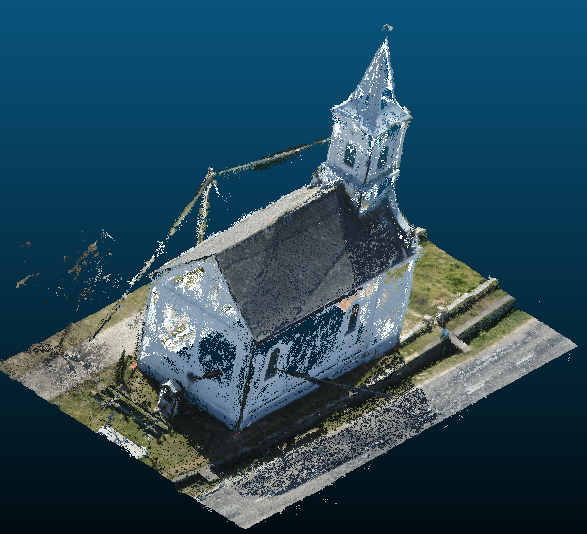

### Statistical Outlier Removal (SOR)

A zaj pontok megtalálása statisztikai alapon. Számítsuk ki minden egyes pontra a **k** legközelebbi szomszéd átlagos távolságát.

$d_i = \frac {1} {k} \sum_{j=1}^k || p_i - p_{ij} ||$

Számítsuk ki ezen távolságok átlagát és szórását

$\mu = \frac 1 {n} \sum_{i=1}^n d_i$

$\sigma = \sqrt \frac {\sum_{i=1}^n (d_i - \mu)^2} {n-1}$

Vizsgáljuk meg minden pontra, hogy a k legközelebbi szomszéd átlagos távolsága nagyobb-e mint a globális átlag szórással megnövelt értéke.

$d_i > \mu + \alpha \cdot \sigma$

$\alpha$ általában 1-3 közé eső konstans.

In [4]:
NB_NEIGHBORS = 25   # szomszédos pontok száma 10 - 50 között
STD_RATIO = 1       # alfa 1-3 között
sor_pc, _ = pc.remove_statistical_outlier(nb_neighbors=NB_NEIGHBORS, std_ratio=STD_RATIO)
o3d.io.write_point_cloud('minta1_sor.ply', sor_pc)
print(f"{len(pc.points)-len(sor_pc.points)} pont eltávolítva a {len(pc.points)} közül, {100-len(sor_pc.points)/len(pc.points)*100:.1f}%.")

130018 pont eltávolítva a 1273830 közül, 10.2%.


### Radius Outlier Removal

A kevés közeli szomszéddal rendelkező pontokat tekintjük zajnak. Minden egyes pontra keressük meg egy R sugarú környezetébe eső pontokat, ha ezek száma egy korlátnál kevesebb, akkor eltávolítjuk a pontot.

In [5]:
RADIUS = 0.3
LIMIT = 10
ror_pc, _ = pc.remove_radius_outlier(nb_points=LIMIT, radius=RADIUS)
o3d.io.write_point_cloud('minta1_ror.ply', ror_pc)
print(f"{len(pc.points)-len(ror_pc.points)} pont eltávolítva a {len(pc.points)} közül, {100-len(ror_pc.points)/len(pc.points)*100:.1f}%.")

3376 pont eltávolítva a 1273830 közül, 0.3%.


### Pontfelhő ritkitása

A pontfelhő ritkítására léteznek nagyon egyszerű módszerek. Például minden n. pont eltávolítása vagy véletlenszerűen válaszott pontok eltávolítása. Ezeknél célszerűbb megoldás a szomszédos pontok közötti minimális távolsággal szűrés. Osszuk fel a pontfelhő pontjait a minimális távolság méretű kis kockákra (voxelekre). A voxelen belül csak egy pontot őrizzünk meg.

In [7]:
VOXEL_SIZE = 0.05  # minimális távolság a pontok között
vox_pc = pc.voxel_down_sample(voxel_size=VOXEL_SIZE)
o3d.io.write_point_cloud('minta1_vox.ply', vox_pc)
print(f"{len(pc.points)-len(vox_pc.points)} pont eltávolítva a {len(pc.points)} közül, {100-len(vox_pc.points)/len(pc.points)*100:.1f}%.")

597679 pont eltávolítva a 1273830 közül, 46.9%.


In [16]:
# nyolcas fa
MAX_DEPTH = 10   # fa mélység a terjedelem és felbontás alapján
octree = o3d.geometry.Octree(max_depth=MAX_DEPTH)
octree.convert_from_point_cloud(pc)
# a ritkított pontok tárolásához
down_points = []
# segédfüggvény a nyolcas fa bejárásához
def traverse(node, node_info):
    if isinstance(node, o3d.geometry.OctreeLeafNode):
        if len(node.indices) > 0:
            pts = np.asarray(pc.points)[node.indices]
            centroid = pts.mean(axis=0)
            down_points.append(centroid)
    return False  # continue traversal
# nyolcas fa bejárása
octree.traverse(traverse)
print(len(down_points))
# pontfelhő a szűrt pontokból
oct_pc = o3d.geometry.PointCloud()
oct_pc.points = o3d.utility.Vector3dVector(np.array(down_points))

# mentés fájlba
o3d.io.write_point_cloud("minta1_oct.ply", oct_pc)
print(f"{len(pc.points)-len(oct_pc.points)} pont eltávolítva a {len(pc.points)} közül, {100-len(oct_pc.points)/len(pc.points)*100:.1f}%.")

[5.50903414e+05 1.82409105e+05 2.81604279e+02] [5.50947448e+05 1.82444303e+05 3.12428375e+02] 10
804256
469574 pont eltávolítva a 1273830 közül, 36.9%.
